# Synthetic Multimodal TUG-DT Workflow

## Goal

Run the public synthetic dataset through the complete pipeline, inspect aggregate quality-control
and modality-availability artifacts, and verify the software contract without presenting any
clinical finding. Synthetic fixtures demonstrate code behavior only.

## Setup

Install the project with `python -m pip install -e '.[dev]'` before executing this notebook. The
cells locate the repository root, run the same public CLI used in the README, and show only
aggregate or synthetic outputs.

In [1]:
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

project_root = Path.cwd()
if not (project_root / "configs" / "example.yaml").is_file():
    project_root = project_root.parent

assert (project_root / "configs" / "example.yaml").is_file()
print("Repository and example configuration found.")

Repository and example configuration found.


## Steps

### 1. Run the end-to-end workflow

The command validates the manifest, preprocesses and synchronizes the supported modalities,
extracts interpretable features, fuses trial-level tables, and writes an aggregate report.

In [2]:
completed = subprocess.run(
    ["tugdt", "run-all", "--config", "configs/example.yaml"],
    cwd=project_root,
    text=True,
    capture_output=True,
    check=True,
)
print("Pipeline completed successfully.")

Pipeline completed successfully.


### 2. Inspect modality availability and quality control

Video is intentionally absent from the committed demo. This tests missing-modality handling
without publishing a face recording or manufacturing a fake clinical video.

In [3]:
features = pd.read_csv(project_root / "outputs/features/multimodal_features.csv")
availability_columns = sorted(
    column for column in features.columns if column.startswith("availability__")
)
availability = (
    features[availability_columns]
    .sum()
    .rename_axis("modality")
    .reset_index(name="available_trials")
)
availability["modality"] = availability["modality"].str.replace("availability__", "", regex=False)
display(availability)

,modality,available_trials
0,audio,2
1,clinical,2
2,footswitch,2
3,imu,2
4,video,0


In [4]:
qc_files = {
    "IMU": "imu_preprocessing.csv",
    "Synchronization": "synchronization.csv",
    "Audio": "audio_processing.csv",
    "Footswitch": "footswitch_processing.csv",
    "Video": "video_processing.csv",
}
qc_rows = []
for stage, filename in qc_files.items():
    frame = pd.read_csv(project_root / "outputs/qc" / filename)
    counts = frame.get("qc_status", pd.Series(dtype=str)).value_counts()
    qc_rows.append(
        {
            "stage": stage,
            "rows": len(frame),
            "pass": int(counts.get("pass", 0)),
            "warning": int(counts.get("warning", 0)),
            "fail": int(counts.get("fail", 0)),
        }
    )
qc_summary = pd.DataFrame(qc_rows)
display(qc_summary)

,stage,rows,pass,warning,fail
0,IMU,2,2,0,0
1,Synchronization,4,4,0,0
2,Audio,2,2,0,0
3,Footswitch,2,2,0,0
4,Video,0,0,0,0


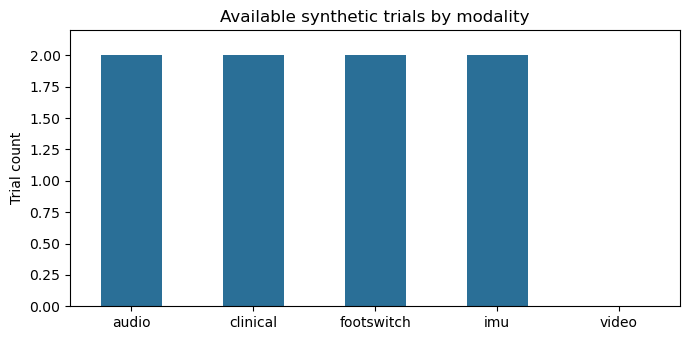

In [5]:
plot_data = availability.set_index("modality")["available_trials"]
ax = plot_data.plot.bar(color="#2A6F97", figsize=(7, 3.5))
ax.set_title("Available synthetic trials by modality")
ax.set_xlabel("")
ax.set_ylabel("Trial count")
ax.set_ylim(0, max(2.2, float(plot_data.max()) + 0.2))
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

### 3. Read the aggregate report

The report deliberately omits participant identifiers, raw paths, and participant-level feature
values. It summarizes whether required software artifacts exist and states the interpretation
boundary.

In [6]:
report_text = (project_root / "outputs/reports/research_summary.md").read_text(encoding="utf-8")
display(Markdown(report_text))

# Multimodal TUG-DT Research Summary

> Aggregate software-generated report. It contains no participant-level measurements and must not be interpreted as a clinical result.

## Dataset contract

| Measure | Count |
|---|---|
| Participants | 1 |
| Trials | 2 |

### Conditions

| Condition | Trials |
|---|---|
| dual_task | 1 |
| single_task | 1 |

### Modality availability

| Modality | Available trials | Missing trials |
|---|---|---|
| imu | 2 | 0 |
| audio | 2 | 0 |
| video | 0 | 2 |
| footswitch | 2 | 0 |
| annotation | 2 | 0 |
| clinical | 2 | 0 |

## Quality-control status

| Stage | Artifact | Rows | Pass | Warning | Fail |
|---|---|---|---|---|---|
| IMU preprocessing | available | 2 | 2 | 0 | 0 |
| Synchronization | available | 4 | 4 | 0 | 0 |
| Audio processing | available | 2 | 2 | 0 | 0 |
| Footswitch processing | available | 2 | 2 | 0 | 0 |
| Video processing | available | 0 | 0 | 0 | 0 |

Warnings require review; they are not silently converted to passes. A row count may refer to trials or modality alignments depending on the stage.

## Derived feature artifacts

| Artifact | Status | Total rows | Trial rows | Phase rows |
|---|---|---|---|---|
| IMU | available | 16 | 2 | 14 |
| Audio | available | 16 | 2 | 14 |
| Footswitch | available | 16 | 2 | 14 |
| Video | available | 0 | 0 | 0 |
| Multimodal trial table | available | 2 | 2 | 0 |

## Modeling status

Baseline modeling is disabled in the example configuration because the public synthetic dataset contains only one independent participant group.

## Reproducibility record

- Configuration file: `example.yaml`
- Clock mapping: `reference_time = native_time + offset_seconds`
- Grouped modeling unit: `participant_id`
- Generated artifacts remain excluded from version control by default.

## Interpretation boundary

This pipeline is research software, not a medical device. Synthetic fixtures demonstrate software behavior only. Sensor features, voice-activity intervals, foot-contact events, video pose proxies, and cross-validated model metrics require protocol-specific validation before scientific or clinical interpretation.


## Checks

These executable checks make the demo's intended behavior auditable: two trials are fused, the
three generated sensor modalities and clinical metadata are available, video remains absent, and
no QC stage reports a failure.

In [7]:
assert len(features) == 2
assert set(features["condition"]) == {"single_task", "dual_task"}
assert features["availability__imu"].eq(1).all()
assert features["availability__audio"].eq(1).all()
assert features["availability__footswitch"].eq(1).all()
assert features["availability__clinical"].eq(1).all()
assert features["availability__video"].eq(0).all()
assert qc_summary["fail"].sum() == 0
print("All synthetic workflow checks passed.")

All synthetic workflow checks passed.


## Next Steps

- Replace synthetic paths with authorized, protocol-specific data through the manifest contract.
- Record real synchronization offsets and uncertainty rather than copying the demo's explicit
  zero offsets.
- Validate sensor and pose proxy features against an appropriate reference standard.
- Enable grouped baseline modeling only after collecting enough independent participant groups.
- Treat all outputs as research artifacts, not diagnostic or medical-device results.